In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("heart.csv")

In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
cat_variable = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

In [ ]:
df = pd.get_dummies(data=df, prefix=cat_variable, columns=cat_variable)

In [ ]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [ ]:
features = [x for x in df.columns if x not in "HeartDisease"]

In [ ]:
print(len(features))

20


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(df[features], df["HeartDisease"], train_size=0.8, shuffle=True)

In [ ]:
x_train.shape

(734, 20)

In [ ]:
y_train.shape

(734,)

In [ ]:
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700]
max_depth_list = [1,2, 3, 4, 8, 16, 32, 64, None]
RANDOM_STATE = 1

In [ ]:
train_acc = []
test_acc = []

for min_samples_split in min_samples_split_list:
  model = DecisionTreeClassifier(min_samples_split = min_samples_split, random_state = RANDOM_STATE).fit(x_train, y_train)
  train_pred = model.predict(x_train)
  test_pred = model.predict(x_test)
  tr_acc = accuracy_score(train_pred, y_train)
  te_acc = accuracy_score(test_pred, y_test)

  train_acc.append(tr_acc)
  test_acc.append(te_acc)

print(train_acc)
print(test_acc)

[1.0, 0.9427792915531336, 0.8896457765667575, 0.8746594005449592, 0.8446866485013624, 0.8365122615803815, 0.8351498637602179, 0.8147138964577657]
[0.7934782608695652, 0.7989130434782609, 0.8532608695652174, 0.8532608695652174, 0.8478260869565217, 0.8369565217391305, 0.8369565217391305, 0.8097826086956522]


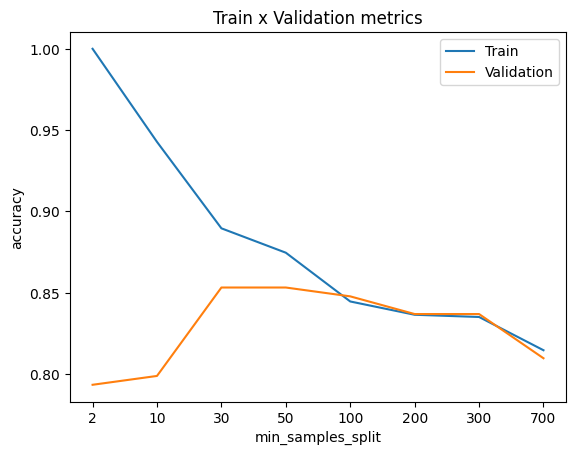

In [ ]:
plt.title('Train x Validation metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list)
plt.plot(train_acc)
plt.plot(test_acc)
plt.legend(['Train','Validation'])

In [ ]:
train_list = []
test_list = []

for max_depth in max_depth_list:
  model = DecisionTreeClassifier(max_depth = max_depth, random_state = RANDOM_STATE).fit(x_train, y_train)
  train_pred = model.predict(x_train)
  test_pred = model.predict(x_test)
  train_max_acc = accuracy_score(train_pred, y_train)
  test_max_acc = accuracy_score(test_pred, y_test)

  train_list.append(train_max_acc)
  test_list.append(test_max_acc)

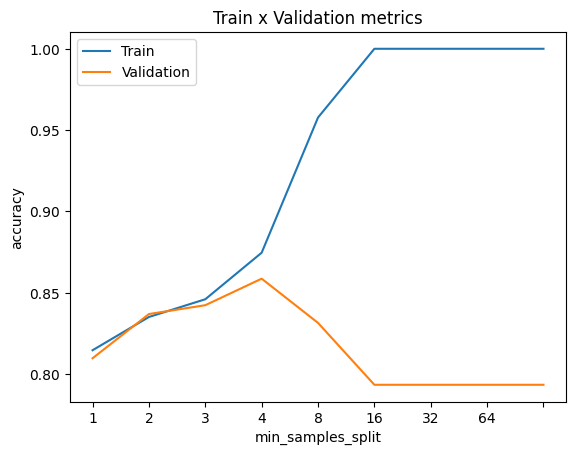

In [ ]:
plt.title('Train x Validation metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list  )),labels=max_depth_list)
plt.plot(train_list)
plt.plot(test_list)
plt.legend(['Train','Validation'])

In [ ]:
model = DecisionTreeClassifier(min_samples_split=50, max_depth=4, random_state=RANDOM_STATE).fit(x_train, y_train)
t_pred = model.predict(x_train)
tt_pred = model.predict(x_test)
train_accu = accuracy_score(t_pred, y_train)
test_accu = accuracy_score(tt_pred, y_test)

print(train_accu, test_accu)

0.8664850136239782 0.8586956521739131
